In [ ]:
!nvidia-smi
!pip install torch torchvision scikit-learn matplotlib seaborn Pillow tqdm numpy -q
import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'\n  Device  : {DEVICE}')
if DEVICE == 'cuda':
    print(f'  GPU     : {torch.cuda.get_device_name(0)}')
    print(f'  Memory  : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('  ⚠️  No GPU — Go to Runtime → Change runtime type → T4 GPU')
print(f'  PyTorch : {torch.__version__}')
print('\n✓ Ready')

Sat Mar 21 15:21:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
from pathlib import Path

RAW_FOLDER = '/content/drive/MyDrive/Colab Notebooks/LeafProject/Leaf_Dataset_Augmented'

if Path(RAW_FOLDER).exists():
    print(f"✅ Folder found!")

    contents = list(Path(RAW_FOLDER).iterdir())
    print(f"\n📂 Contents ({len(contents)} items):")
    for item in contents:
        if item.is_dir():
            jpg_count = len(list(item.rglob('*.jpg'))) + len(list(item.rglob('*.png')))
            print(f"   📁 {item.name}  ({jpg_count} images)")
        else:
            print(f"   📄 {item.name}")

    # Count total images
    total_jpgs = len(list(Path(RAW_FOLDER).rglob('*.jpg')))
    total_pngs = len(list(Path(RAW_FOLDER).rglob('*.png')))
    print(f"\n🖼️  Total images: {total_jpgs + total_pngs}")
    print(f"\n✅ RAW_FOLDER is ready to use!")
else:
    print("❌ Still not found!")

✅ Folder found!

📂 Contents (10 items):
   📁 Madagascar_Sadabhar  (240 images)
   📁 Neem  (216 images)
   📁 Mango  (201 images)
   📁 gulmohar  (220 images)
   📁 Lily_Nagdamani  (240 images)
   📁 paper_flower  (200 images)
   📁 Ashok  (200 images)
   📁 banana  (200 images)
   📁 Jamun  (202 images)
   📁 blackboard  (215 images)

🖼️  Total images: 2134

✅ RAW_FOLDER is ready to use!


In [ ]:
%matplotlib inline
import os, shutil, random, time, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils
import torchvision.transforms as T
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader, random_split, Subset, WeightedRandomSampler
from torchvision.datasets import ImageFolder

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams['figure.dpi'] = 110
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tqdm.notebook import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✓ Device: {DEVICE}')

✓ Device: cuda


In [ ]:
# ══════════════════════════════════════════════
#  SETTINGS
# ══════════════════════════════════════════════
# RAW_FOLDER set in Cell 2
# Uncomment if needed:
# RAW_FOLDER = '/content/Leave-Small'

AUGMENT_FOLDER   = '/content/augmented_dataset'
CHECKPOINT_DIR   = '/content/checkpoints'
OUTPUT_DIR       = '/content/outputs'

IMAGE_SIZE       = 224
BATCH_SIZE       = 32      # matches original code
AUGMENTS_PER_IMG = 1       # 4000 × 2 = 8000 images
SSL_EPOCHS       = 50      # matches original code
FT_EPOCHS        = 25      # matches original code
TEMPERATURE      = 0.5
FEATURE_DIM      = 128
SSL_LR           = 1e-3
FT_LR            = 1e-3
NUM_WORKERS      = 2

SSL_CKPT   = os.path.join(CHECKPOINT_DIR, 'mbmu_simclr_grayscale_model.pth')
FINAL_CKPT = os.path.join(CHECKPOINT_DIR, 'final_model.pth')

for d in [AUGMENT_FOLDER, CHECKPOINT_DIR, OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)

species = [d.name for d in Path(RAW_FOLDER).iterdir() if d.is_dir()]
print(f'✓ Config ready')
print(f'  Species    : {len(species)} — {species}')
print(f'  Batch size : {BATCH_SIZE}')
print(f'  SSL epochs : {SSL_EPOCHS}')
print(f'  FT epochs  : {FT_EPOCHS}')
print(f'  Device     : {DEVICE}')

✓ Config ready
  Species    : 10 — ['Madagascar_Sadabhar', 'Neem', 'Mango', 'gulmohar', 'Lily_Nagdamani', 'paper_flower', 'Ashok', 'banana', 'Jamun', 'blackboard']
  Batch size : 32
  SSL epochs : 50
  FT epochs  : 25
  Device     : cuda


  STEP 1 — Load Raw Dataset
  Ashok                           200 images  ████████████████████
  Jamun                           202 images  ████████████████████
  Lily_Nagdamani                  240 images  ████████████████████████
  Madagascar_Sadabhar             240 images  ████████████████████████
  Mango                           201 images  ████████████████████
  Neem                            216 images  █████████████████████
  banana                          200 images  ████████████████████
  blackboard                      215 images  █████████████████████
  gulmohar                        220 images  ██████████████████████
  paper_flower                    200 images  ████████████████████

  Total species : 10
  Total images  : 2134


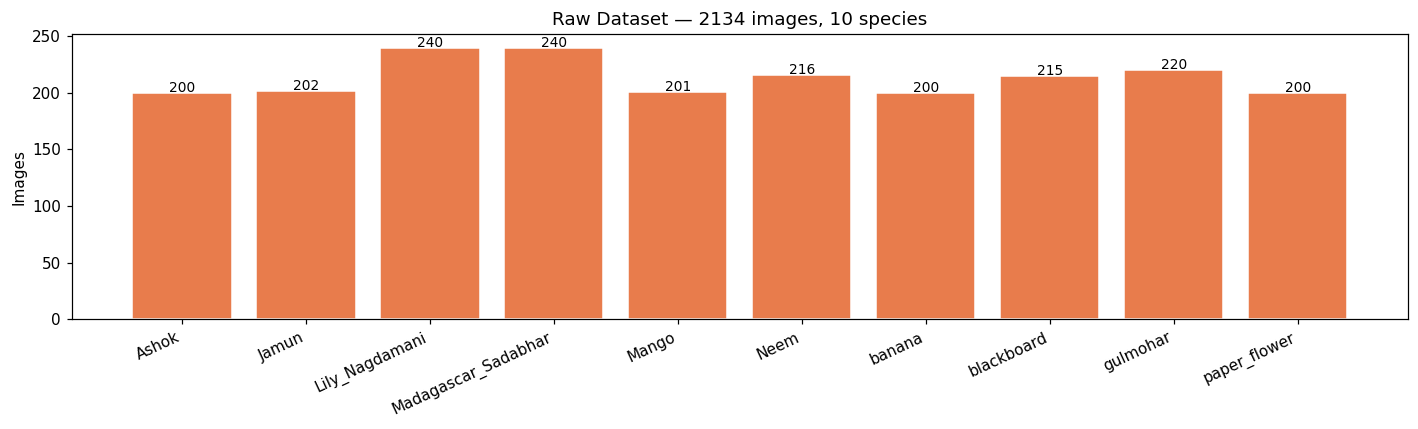

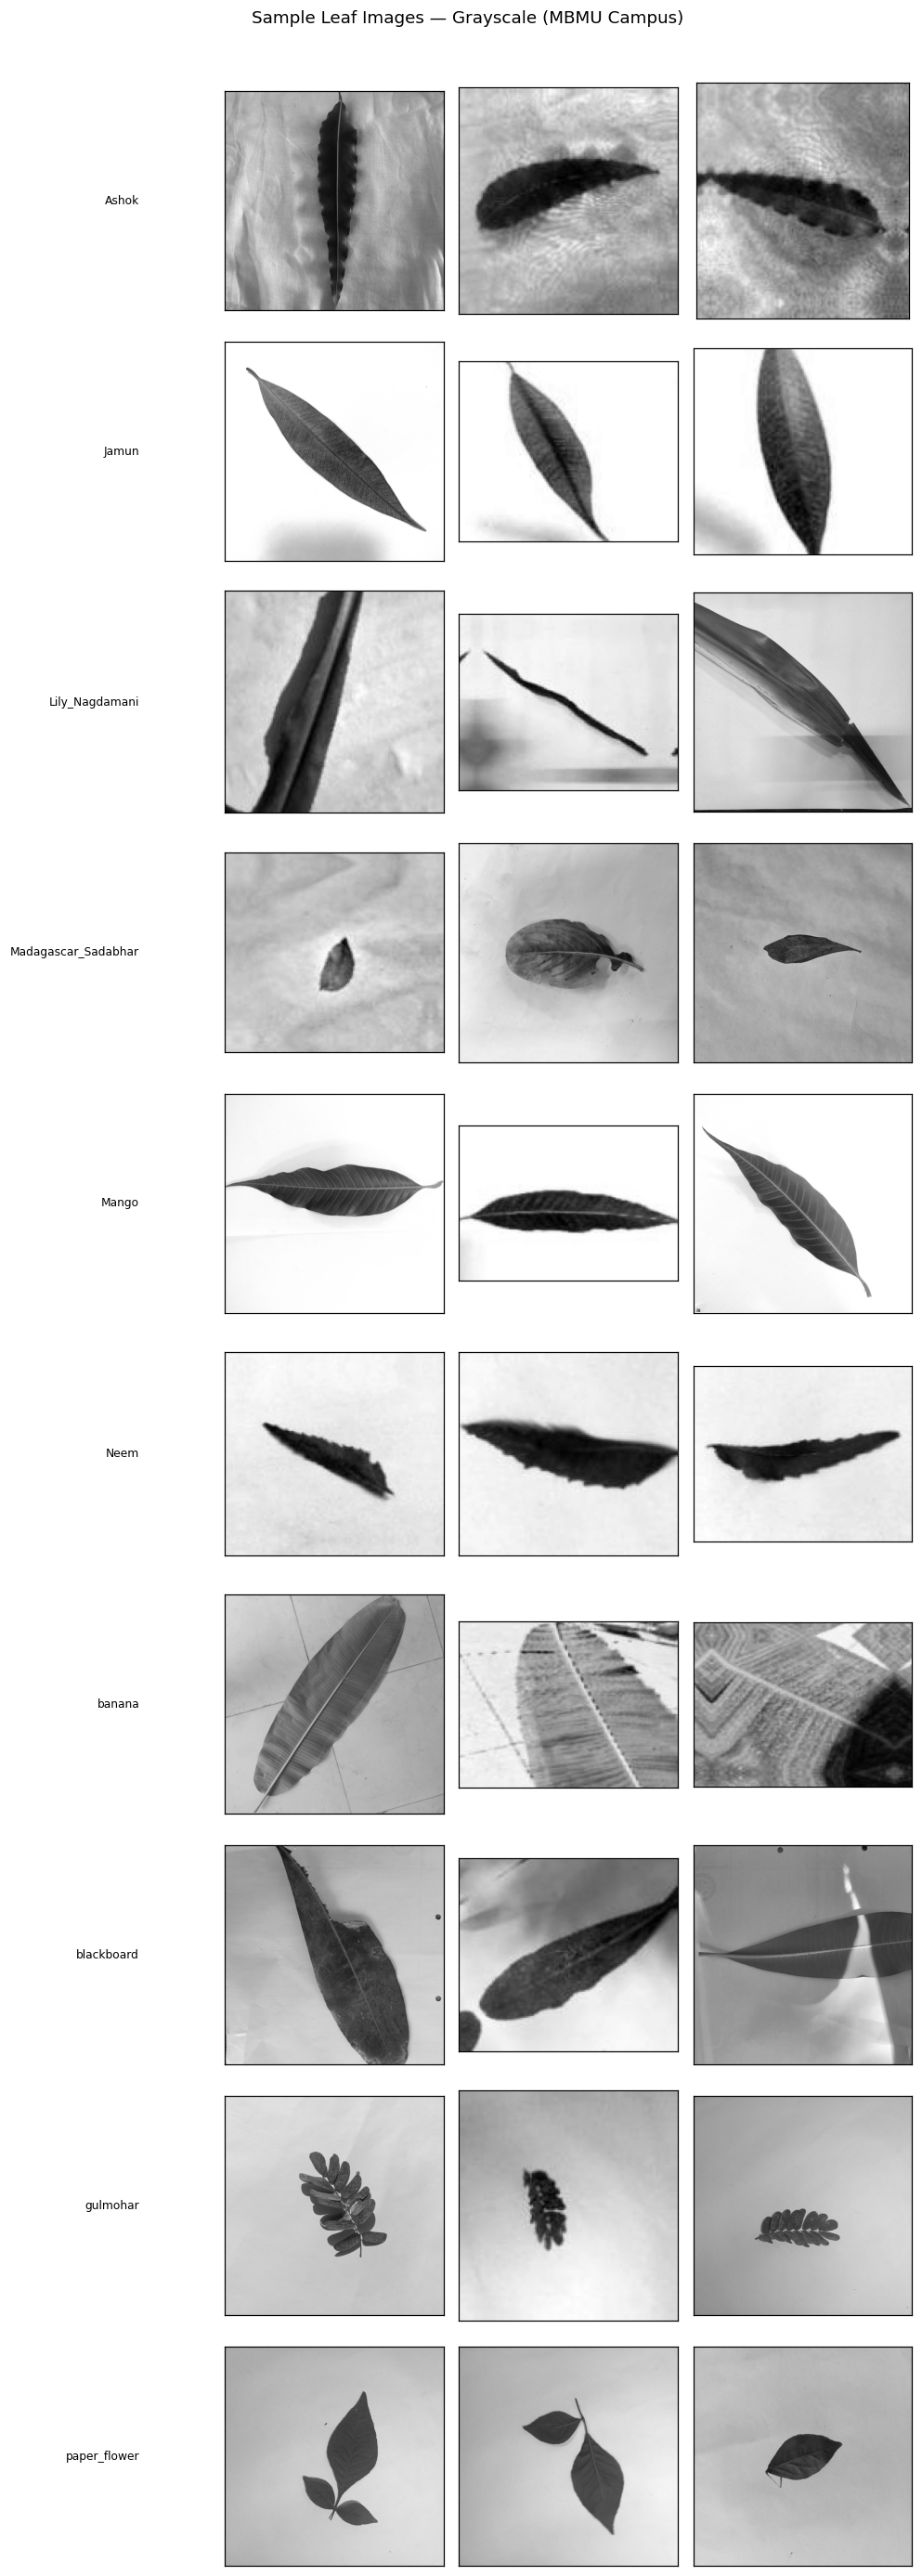

✓ Charts saved


In [ ]:
print('='*55)
print('  STEP 1 — Load Raw Dataset')
print('='*55)

raw_species   = {}
all_img_paths = []
for sp_dir in sorted(Path(RAW_FOLDER).iterdir()):
    if not sp_dir.is_dir(): continue
    imgs = list(sp_dir.glob('*.jpg')) + list(sp_dir.glob('*.JPG'))
    if not imgs: continue
    raw_species[sp_dir.name] = imgs
    all_img_paths.extend(imgs)
    print(f'  {sp_dir.name:<30} {len(imgs):>4} images  {"█"*(len(imgs)//10)}')

print(f'\n  Total species : {len(raw_species)}')
print(f'  Total images  : {len(all_img_paths)}')

# Distribution chart
plt.figure(figsize=(13, 4))
bars = plt.bar(raw_species.keys(), [len(v) for v in raw_species.values()],
               color='#E87C4C', edgecolor='white')
for b in bars:
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+1,
             str(int(b.get_height())), ha='center', fontsize=9)
plt.title(f'Raw Dataset — {len(all_img_paths)} images, {len(raw_species)} species')
plt.ylabel('Images'); plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'raw_distribution.png'), dpi=150)
plt.show()

# Sample images
n_sp = len(raw_species)
fig, axes = plt.subplots(n_sp, 3, figsize=(9, n_sp*2.5))
for row,(sp_name,img_list) in enumerate(raw_species.items()):
    samples = random.sample(img_list, min(3, len(img_list)))
    for col in range(3):
        ax = axes[row][col] if n_sp>1 else axes[col]
        if col<len(samples):
            ax.imshow(Image.open(samples[col]).convert('L'), cmap='gray')
            if col==0: ax.set_ylabel(sp_name, fontsize=8, rotation=0,
                                     ha='right', va='center', labelpad=60)
        ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Sample Leaf Images — Grayscale (MBMU Campus)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'sample_images.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Charts saved')

In [ ]:
print('='*55)
print('  STEP 2 — Augment Dataset')
print(f'  {len(all_img_paths)} × {AUGMENTS_PER_IMG+1} = ~{len(all_img_paths)*(AUGMENTS_PER_IMG+1)} images')
print('='*55)

if Path(AUGMENT_FOLDER).exists():
    total = sum(len(list(sp.glob('*.jpg'))) for sp in Path(AUGMENT_FOLDER).iterdir() if sp.is_dir())
    if total > 1000:
        print(f'✓ Already exists: {total:,} images — skipping'); SKIP_AUG=True
    else: SKIP_AUG=False
else: SKIP_AUG=False

if not SKIP_AUG:
    # Same augmentation transforms from original code
    AUG_TRANSFORMS = T.Compose([
        T.Grayscale(num_output_channels=1),
        T.RandomResizedCrop(size=IMAGE_SIZE, scale=(0.5, 1.0)),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomApply([T.ColorJitter(brightness=0.4, contrast=0.4)], p=0.8),
        T.ToTensor(),
        T.Normalize(mean=[0.5], std=[0.5])
    ])

    def augment_one(img_pil, n):
        base = T.Compose([T.Grayscale(1), T.Resize((IMAGE_SIZE, IMAGE_SIZE))])
        img  = base(img_pil); out=[]
        for _ in range(n):
            try:
                aug = T.Compose([
                    T.Grayscale(1),
                    T.RandomResizedCrop(IMAGE_SIZE, scale=(0.5,1.0)),
                    T.RandomHorizontalFlip(0.5),
                    T.RandomApply([T.ColorJitter(brightness=0.4,contrast=0.4)], p=0.8),
                ])(img_pil)
                aug = T.Resize((IMAGE_SIZE,IMAGE_SIZE))(aug)
            except: aug=img
            out.append(aug)
        return out

    print(f'\n  {"Species":<30} {"Orig":>6}  {"Total":>8}')
    print(f'  {"-"*48}')
    total_orig=total_aug=0

    for sp_dir in sorted(Path(RAW_FOLDER).iterdir()):
        if not sp_dir.is_dir(): continue
        sp_clean = sp_dir.name.replace('(','').replace(')','').replace(' ','_').strip()
        out_dir  = Path(AUGMENT_FOLDER)/sp_clean
        out_dir.mkdir(parents=True, exist_ok=True)
        imgs  = list(sp_dir.glob('*.jpg'))+list(sp_dir.glob('*.JPG'))
        sp_tot=0
        for img_path in imgs:
            shutil.copy2(img_path, out_dir/img_path.name); sp_tot+=1
            try:
                for j,aug in enumerate(augment_one(Image.open(img_path), AUGMENTS_PER_IMG)):
                    aug.save(str(out_dir/f'{img_path.stem}_aug{j+1:03d}.jpg'),'JPEG',quality=92)
                    sp_tot+=1
            except: pass
        total_orig+=len(imgs); total_aug+=sp_tot
        print(f'  {sp_clean:<30} {len(imgs):>6}  {sp_tot:>8}')

    print(f'  {"-"*48}')
    print(f'  {"TOTAL":<30} {total_orig:>6}  {total_aug:>8}')
    print(f'\n✓ Augmentation complete')

  STEP 2 — Augment Dataset
  2134 × 2 = ~4268 images

  Species                          Orig     Total
  ------------------------------------------------
  Ashok                             200       400
  Jamun                             202       404
  Lily_Nagdamani                    240       480
  Madagascar_Sadabhar               240       480
  Mango                             201       402
  Neem                              216       432
  banana                            200       400
  blackboard                        215       430
  gulmohar                          220       440
  paper_flower                      200       400
  ------------------------------------------------
  TOTAL                            2134      4268

✓ Augmentation complete


  Ashok                            400  ████████
  Jamun                            404  ████████
  Lily_Nagdamani                   480  █████████
  Madagascar_Sadabhar              480  █████████
  Mango                            402  ████████
  Neem                             432  ████████
  banana                           400  ████████
  blackboard                       430  ████████
  gulmohar                         440  ████████
  paper_flower                     400  ████████

  Total   : 4,268 images
  Species : 10 — ['Ashok', 'Jamun', 'Lily_Nagdamani', 'Madagascar_Sadabhar', 'Mango', 'Neem', 'banana', 'blackboard', 'gulmohar', 'paper_flower']


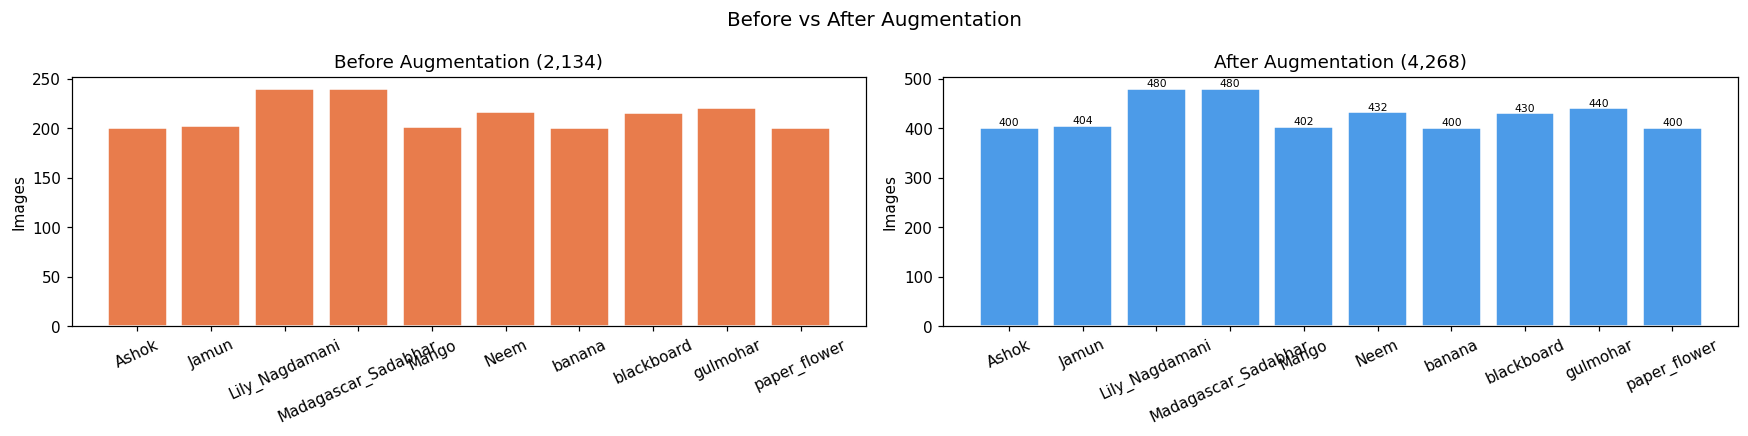

✓ Dataset verified — ready for training


In [ ]:
aug_counts={}; grand_total=0
for sp in sorted(Path(AUGMENT_FOLDER).iterdir()):
    if not sp.is_dir(): continue
    n=len(list(sp.glob('*.jpg'))+list(sp.glob('*.JPG')))
    aug_counts[sp.name]=n; grand_total+=n
    print(f'  {sp.name:<30} {n:>5}  {"█"*(n//50)}')

CLASS_NAMES=sorted(aug_counts.keys()); NUM_CLASSES=len(CLASS_NAMES)
print(f'\n  Total   : {grand_total:,} images')
print(f'  Species : {NUM_CLASSES} — {CLASS_NAMES}')

fig,axes=plt.subplots(1,2,figsize=(16,4))
raw_clean={k.replace('(','').replace(')','').replace(' ','_'):len(v) for k,v in raw_species.items()}
axes[0].bar(raw_clean.keys(), raw_clean.values(), color='#E87C4C', edgecolor='white')
axes[0].set_title(f'Before Augmentation ({len(all_img_paths):,})')
axes[0].set_ylabel('Images'); axes[0].tick_params(axis='x',rotation=25)
b2=axes[1].bar(aug_counts.keys(), aug_counts.values(), color='#4C9BE8', edgecolor='white')
for b in b2:
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+5,
                 str(b.get_height()), ha='center', fontsize=7)
axes[1].set_title(f'After Augmentation ({grand_total:,})')
axes[1].set_ylabel('Images'); axes[1].tick_params(axis='x',rotation=25)
plt.suptitle('Before vs After Augmentation', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'before_after.png'),dpi=150)
plt.show()
print('✓ Dataset verified — ready for training')